# Bitcoin Price Regression Analysis

## Problem

What do the historical prices of major cryptocurrencies look like for the past five years?

Do cryptocurrency prices show any relationship to other US financial market prices such as US indices, commodities, and US treasury yields?

Can we model bitcoin prices using information from US financial markets?

## Project Description / Abstract

Crypto currency is fast, international, secured by blockchain technology, and it’s free to use with no permission access by the government. In order to understand how the prices of various crypto currencies fluctuate and whether they are impacted by the US financial market prices, we compared the daily prices from the past five years to the prices of various large cap US indices, commodities, and US treasury yields. In order to see whether there is any relationship between crypto currency prices and US financial market prices, we calculated the pairwise correlations of each of the variables. Using the highly correlated variables, we then trained a Linear Regression model and compared the predicted and actual prices to assess the model.

## Introduction

Crypto currency is the future! Crypto Currency has revolutionized digital transactions and payments between individuals, making it much easier for people to send money to each other even when they live in different countries. It’s also a way for people to build their portfolios and learn about the different types of markets out there to see how they are reacting towards society. In order to understand the influence and popularity of crypto currencies better, we did our extensive research about the price history of several crypto currencies to widely used large cap financial indices as well as historical prices of commodities such as oil and gold. We looked at data from the past 5 years to see how it changed drastically as time went by. Not only did we include data from recent years, but we formatted it in a single data frame for easier access and manipulation of the data.

What are we trying to accomplish from this project? The main goal for us is to briefly look at the recent timeline and stages of crypto currency. We want to show the various kinds of crypto currencies so potential investors can start investing and how they performed over a period of time and how they changed. We will show you our data that will explain the process on how to compare and contrast different types of markets. We also included large cap US indices such as S&P 500, DowJones, and the price of commodities such as Oil, Gold, and the US Treasury yield curve by downloading data from R libraries and financial websites. The data will show a live feedback report up to date at a specific time and we gathered all of the data into a single data frame.

## Datasets being used

We collected data from two sources: the qrmtools R library and quandl.com. We gathered information on the daily prices for large cap indices including S&P 500, Dow Jones, NASDAQ 100; a volatility index VIX, cryptocurrency costs in USD for Bitcoin, Etherium, Lite Coin, Ripple, and the prices of commodities in USD for oil and gold; and the US Treasury Zero-Coupon Yield Curves. We collected data from 2015 October 20th to 2020 October 20th. There was data from 1295 days. We used the tidyverse and zoo packages to clean and manipulate data. We used the ggplot2 and PerformanceAnalytics package to plot the data.

## Literiture survey

In the recent years, crypto currencies have become widely known and invested by individuals. Nowadays, crypto currencies are getting a larger market and many people are looking to invest in it as a way of earning money, similar to the stock market. 

Especially with the rise of the popularity, people have tried many methods to model and predict the prices of crypto currencies. Some models try to predict crypto currency prices by analyzing the sentiment of news articles or posts in online communities or social media. They think that when there are a lot of negative or positive posts, that will have an impact on the crypto currency prices because people will read those posts and decide whether to sell or buy crypto currencies. 

Another way people use psychology to understand crypto currency prices is by looking at the historical data and trying to find patterns in it such as when the crypto currency markets are bearish or bullish. 

## Project Methodology

1. We first searched for financial datasets with historical prices that we could use. We found that the qrmtools R library provided a lot of this information for free.

2. We explored the data and tried to decide which data to pull out. We ended up checking out daily prices for large cap indices including S&P 500, Dow Jones, NASDAQ 100; a volatility index VIX, cryptocurrency costs in USD for Bitcoin, Etherium, Lite Coin, Ripple, and the prices of commodities in USD for oil and gold; and the US Treasury Zero-Coupon Yield Curves. We collected data from 2015 October 20th to 2020 October 20th. There was data from 1295 days.

3. Some of the data had missing information for certain days. For that, we used the na.approx() function which replaces missing data with interpolated values.

4. We included a day column which is the number of days from the first date of 2015 October 20th to use instead of the date column.

5. We gathered all of the data into a single data frame using the tidyverse left_join function.

6. We looked at several plots to understand the distribution and relationship of the data between the variables such as ggplot2’s geom_histogram function to make histograms, or the pairs function to look at scatter plots, and also the PerformanceAnalytics library’s chart.Correlation to calculate and visualize the correlation between the variables.

7. For the bitcoin prices, we used ggplot2’s geom_point function to graph out the historical prices from the past five years.

8. For the variables that had a high correlation value with bitcoin prices, we used ggplot2’s geom_point function to plot the variable price compared to the bitcoin price.

9. We then used the lm function to make a linear regression model with bitcoin price as the variable and S&P 500 and Dow Jones prices as the predictors.

10. We used the summary function on the output of the linear model to check the statistics of the model.

11. We then plot out the diagnostic plots from the linear model using the plot function. 

12. Using the postResample function in the caret library we calculated various values such as r squared value to evaluate the models.

13. We plotted the predicted values versus the actual values. 

## Analysis & Results 

In [ ]:
library(qrmtools) 
library(tidyverse)
library(ggplot2)
library(zoo)
library(PerformanceAnalytics)
library(e1071)
library(caret)

Warning message:
"package 'qrmtools' was built under R version 3.6.3"Registered S3 method overwritten by 'xts':
  method     from
  as.zoo.xts zoo 
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 
Warning message:
"package 'tidyverse' was built under R version 3.6.3"-- Attaching packages --------------------------------------- tidyverse 1.3.0 --
√ ggplot2 3.3.2     √ purrr   0.3.4
√ tibble  3.0.4     √ dplyr   1.0.2
√ tidyr   1.1.2     √ stringr 1.4.0
√ readr   1.3.1     √ forcats 0.4.0
Warning message:
"package 'ggplot2' was built under R version 3.6.3"Warning message:
"package 'tibble' was built under R version 3.6.3"Warning message:
"package 'tidyr' was built under R version 3.6.3"Warning message:
"package 'purrr' was built under R version 3.6.3"Warning message:
"package 'dplyr' was built under R version 3.6.3"-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dpl

In [ ]:
# We will look at data from the past 5 years
time1 = "2015-10-20"
time2 <- "2020-10-20"

In [ ]:
# Gathering the data into a single data frame

# S&P500
SP500 <- get_data("^GSPC", from = time1, to = time2) %>% 
  as.data.frame() %>% 
  rownames_to_column("date") %>%
  rename("SP500" = "^GSPC")

# Dow Jones
DJ <- get_data("^DJI", from = time1, to = time2)  %>% 
  as.data.frame() %>% 
  rownames_to_column("date") %>%
  rename("DowJones" = "^DJI")

# NASDAQ100
NASDAQ <- get_data("^NDX", from = time1, to = time2)  %>% 
  as.data.frame() %>% 
  rownames_to_column("date") %>%
  rename("NASDAQ100" = "^NDX")

# VIX
VIX <- get_data("^VIX", from = time1, to = time2) %>% 
  as.data.frame() %>% 
  rownames_to_column("date") %>%
  rename("VIX" = "^VIX")

# Bitcoin
BTC_USD <- get_data("BTC-USD", from = time1, to = time2) %>% 
  na.approx() %>%
  as.data.frame() %>% 
  rownames_to_column("date") %>%
  rename("BTC" = "BTC-USD")

# Ethereum
ETH_USD <- get_data("ETH-USD", from = time1, to = time2) %>% 
  na.approx() %>%
  as.data.frame() %>% 
  rownames_to_column("date") %>%
  rename("ETH" = "ETH-USD")

# Litecoin
LTC_USD <- get_data("LTC-USD", from = time1, to = time2) %>% 
  na.approx() %>%
  as.data.frame() %>% 
  rownames_to_column("date") %>%
  rename("LTC" = "LTC-USD")

# Ripple
XRP_USD <- get_data("XRP-USD", from = time1, to = time2) %>% 
  na.approx() %>%
  as.data.frame() %>% 
  rownames_to_column("date") %>%
  rename("XRP" = "XRP-USD")

# Oil in USD per barrel
Oil <- get_data("FRED/DCOILBRENTEU", from = time1, to = time2, src = "quandl") %>% 
  na.approx() %>%
  as.data.frame() %>% 
  rownames_to_column("date") %>%
  rename("Oil" = "FRED/DCOILBRENTEU")

# Gold
Gold <- get_data("WGC/GOLD_DAILY_USD", from = time1, to = time2, src = "quandl") %>% 
  na.approx() %>%
  as.data.frame() %>% 
  rownames_to_column("date") %>%
  rename("Gold" = "WGC/GOLD_DAILY_USD")

# US Treasury Yield Curve
US_treasury <- get_data("FED/SVENY", from = time1, to = time2, src = "quandl") %>% 
  na.approx() %>%
  as.data.frame() %>% 
  rownames_to_column("date") %>%
  dplyr::select(SVENY01, SVENY05, SVENY10, SVENY20, SVENY30, date)

df <- left_join(SP500, DJ, by = "date")
df <- left_join(df, NASDAQ, by = "date")
df <- left_join(df, VIX, by = "date")
df <- left_join(df, BTC_USD, by = "date")
df <- left_join(df, ETH_USD, by = "date")
df <- left_join(df, LTC_USD, by = "date")
df <- left_join(df, XRP_USD, by = "date")
df <- left_join(df, Oil, by = "date")
df <- left_join(df, Gold, by = "date")
df <- left_join(df, US_treasury, by = "date")

df <- arrange(df, date) 
df$day <- as.numeric(rownames(df))

'getSymbols' currently uses auto.assign=TRUE by default, but will
use auto.assign=FALSE in 0.5-0. You will still be able to use
'loadSymbols' to automatically load data. getOption("getSymbols.env")
and getOption("getSymbols.auto.assign") will still be checked for
alternate defaults.

This message is shown once per session and may be disabled by setting 
options("getSymbols.warning4.0"=FALSE). See ?getSymbols for details.



In [ ]:
summary(df)

     date               SP500         DowJones       NASDAQ100    
 Length:1259        Min.   :1829   Min.   :15660   Min.   : 3948  
 Class :character   1st Qu.:2273   1st Qu.:19912   1st Qu.: 5061  
 Mode  :character   Median :2665   Median :24264   Median : 6703  
                    Mean   :2623   Mean   :23130   Mean   : 6746  
                    3rd Qu.:2899   3rd Qu.:26049   3rd Qu.: 7681  
                    Max.   :3581   Max.   :29551   Max.   :12421  
                                                                  
      VIX             BTC               ETH                 LTC         
 Min.   : 9.14   Min.   :  266.3   Min.   :   0.4348   Min.   :  2.969  
 1st Qu.:12.33   1st Qu.:  927.6   1st Qu.:  13.4570   1st Qu.:  4.123  
 Median :14.64   Median : 5780.9   Median : 181.1863   Median : 46.284  
 Mean   :17.31   Mean   : 5415.1   Mean   : 219.4913   Mean   : 53.754  
 3rd Qu.:19.33   3rd Qu.: 8771.1   3rd Qu.: 295.7265   3rd Qu.: 68.060  
 Max.   :82.69   Max.   :1

'data.frame':	1259 obs. of  17 variables:
 $ date     : chr  "2015-10-20" "2015-10-21" "2015-10-22" "2015-10-23" ...
 $ SP500    : num  2031 2019 2053 2075 2071 ...
 $ DowJones : num  17217 17169 17489 17647 17623 ...
 $ NASDAQ100: num  4438 4414 4503 4624 4631 ...
 $ VIX      : num  15.8 16.7 14.4 14.5 15.3 ...
 $ BTC      : num  269 266 274 276 285 ...
 $ ETH      : num  0.435 0.447 0.568 0.54 0.731 ...
 $ LTC      : num  3.09 3.08 3.11 3.11 3.1 ...
 $ XRP      : num  0.00473 0.0047 0.00472 0.00468 0.00468 ...
 $ Oil      : num  46.9 46.7 46.6 46.3 46.6 ...
 $ Gold     : num  1178 1167 1167 1161 1166 ...
 $ SVENY01  : num  0.357 0.357 0.371 0.372 0.382 ...
 $ SVENY05  : num  1.45 1.42 1.41 1.48 1.46 ...
 $ SVENY10  : num  2.17 2.12 2.12 2.18 2.15 ...
 $ SVENY20  : num  2.76 2.7 2.71 2.75 2.71 ...
 $ SVENY30  : num  3.2 3.15 3.12 3.15 3.12 ...
 $ day      : num  1 2 3 4 5 6 7 8 9 10 ...


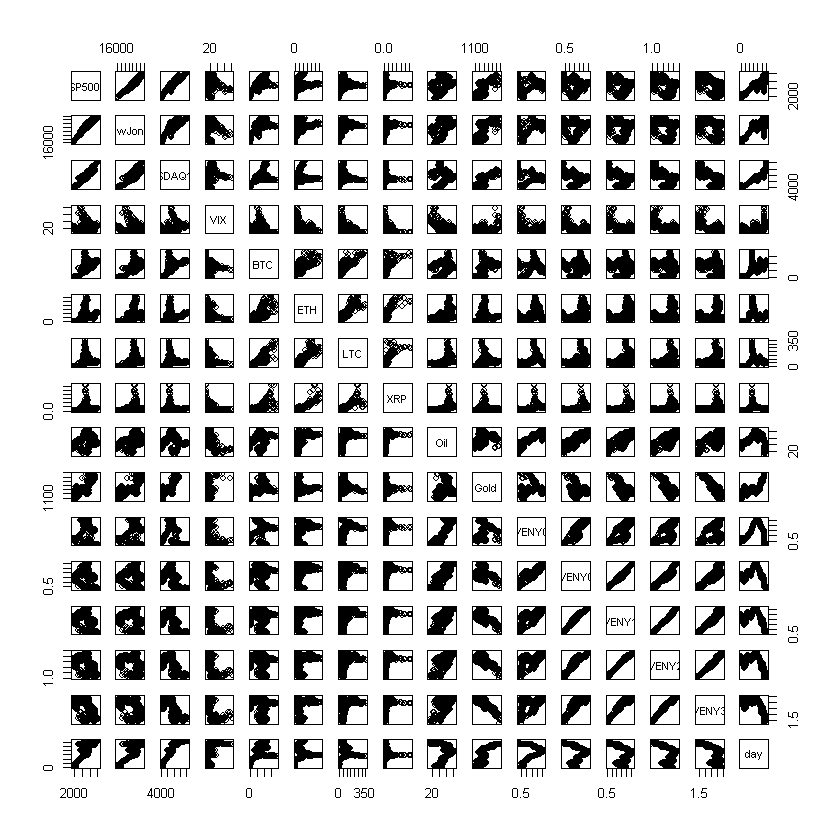

In [ ]:
numeric_df <- dplyr::select(df, -date)
str(df)
pairs(numeric_df)

Warning message:
"Removed 217 rows containing non-finite values (stat_bin)."

null device 
          1

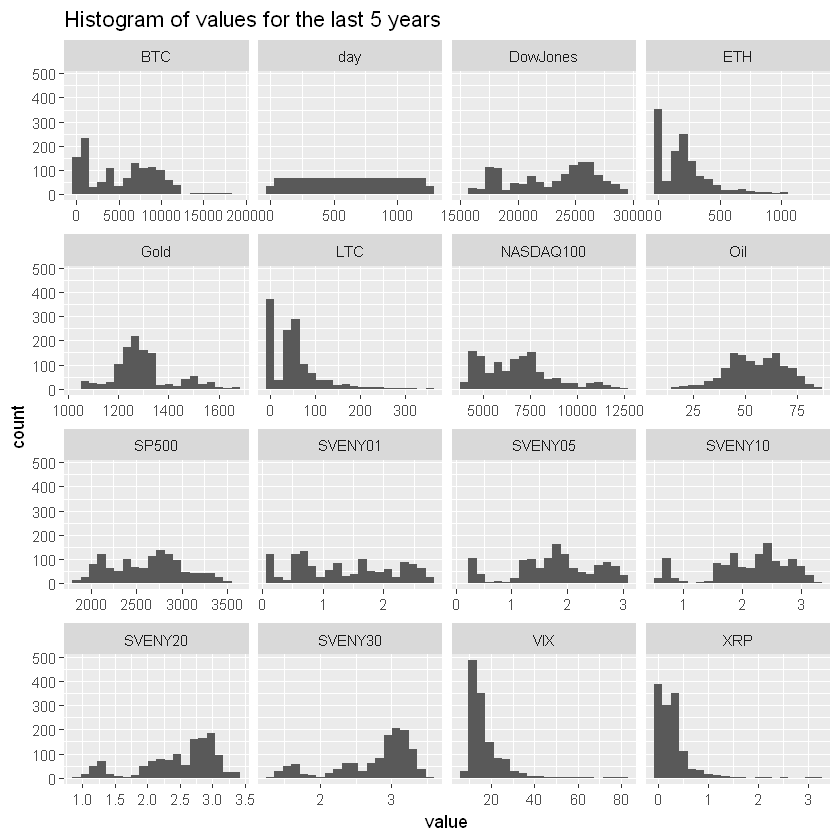

In [ ]:
ggplot(gather(numeric_df), aes(value)) + 
  geom_histogram(bins = 20) + 
  facet_wrap(~key, scales = 'free_x') +
  ggtitle("Histogram of values for the last 5 years")
dev.off()

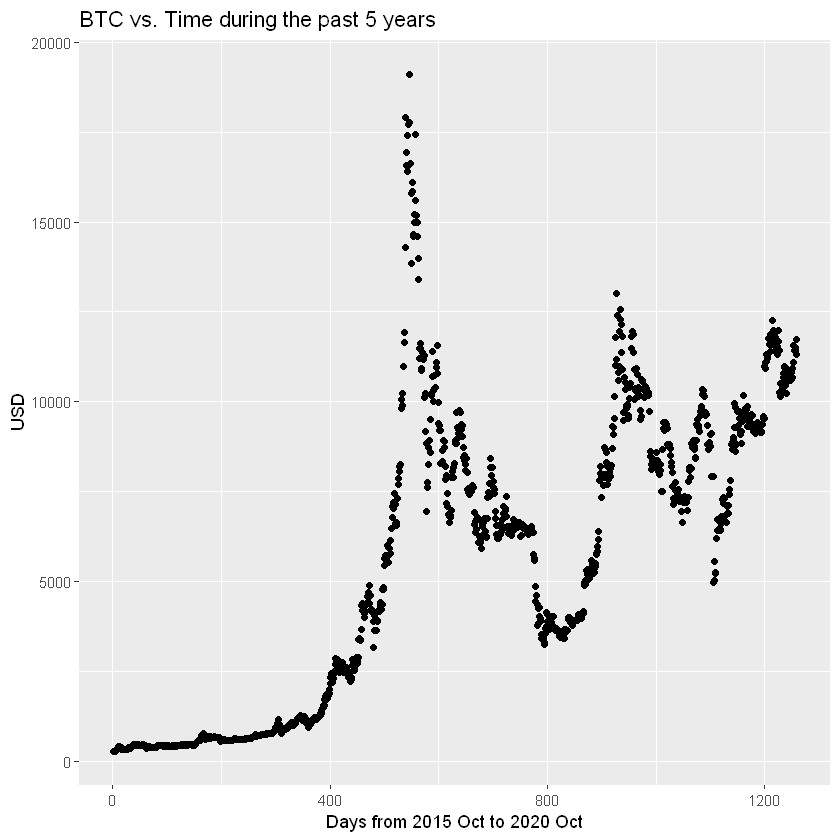

In [ ]:
ggplot(numeric_df, aes(day, BTC)) + 
  geom_point() +
  ggtitle('BTC vs. Time during the past 5 years') +
  labs(x="Days from 2015 Oct to 2020 Oct", y="USD")

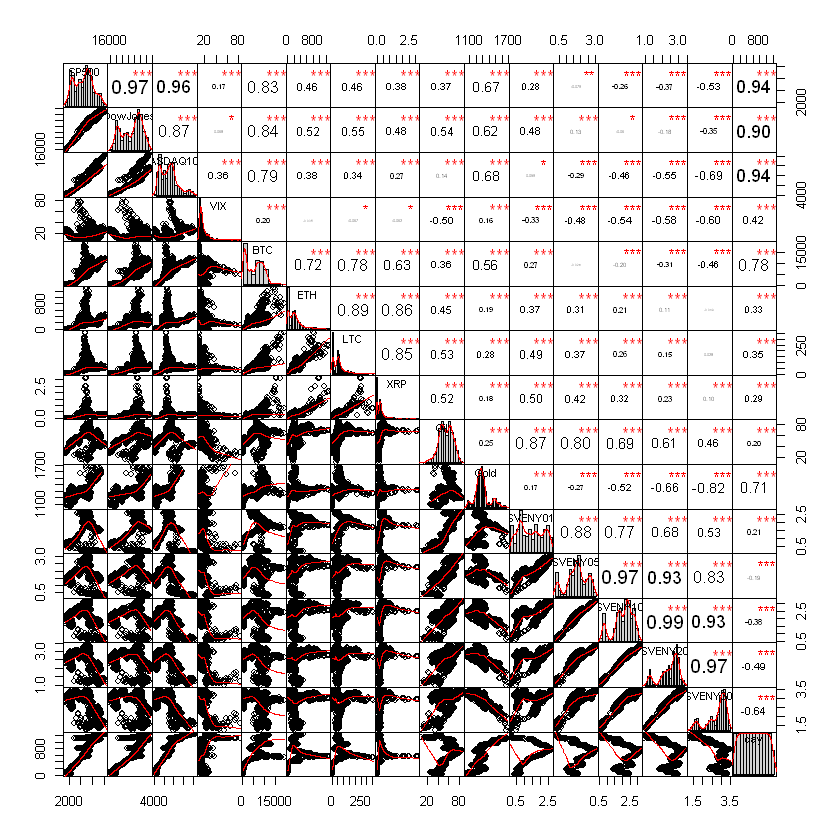

In [ ]:
chart.Correlation(numeric_df, histogram=TRUE, pch=19)

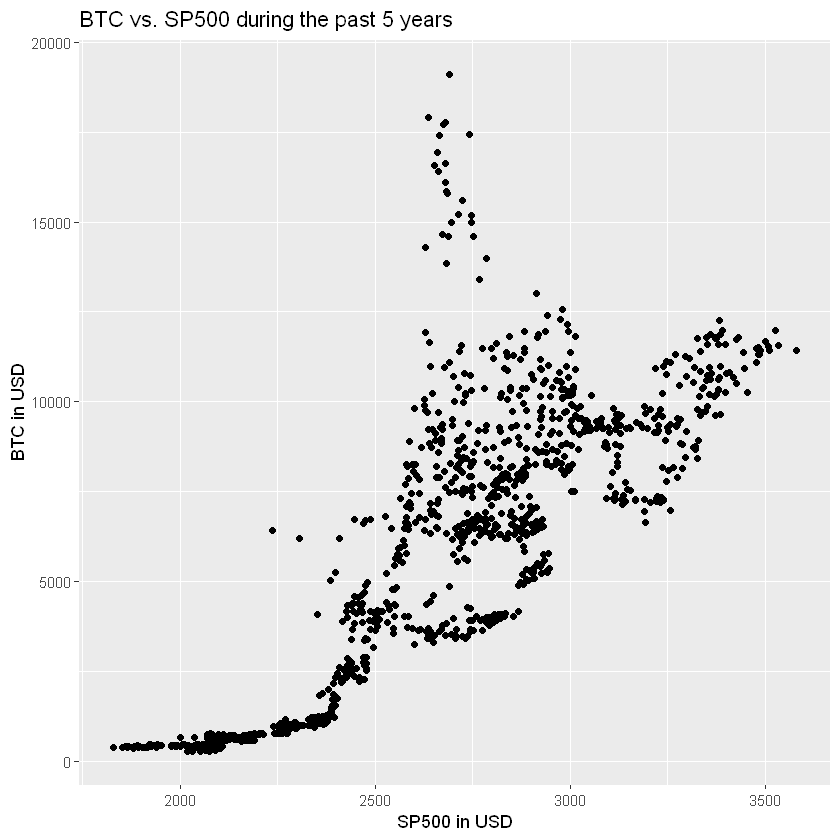

In [ ]:
ggplot(df, aes(SP500, BTC)) + 
  geom_point() +
  ggtitle('BTC vs. SP500 during the past 5 years') +
  labs(x="SP500 in USD", y="BTC in USD")

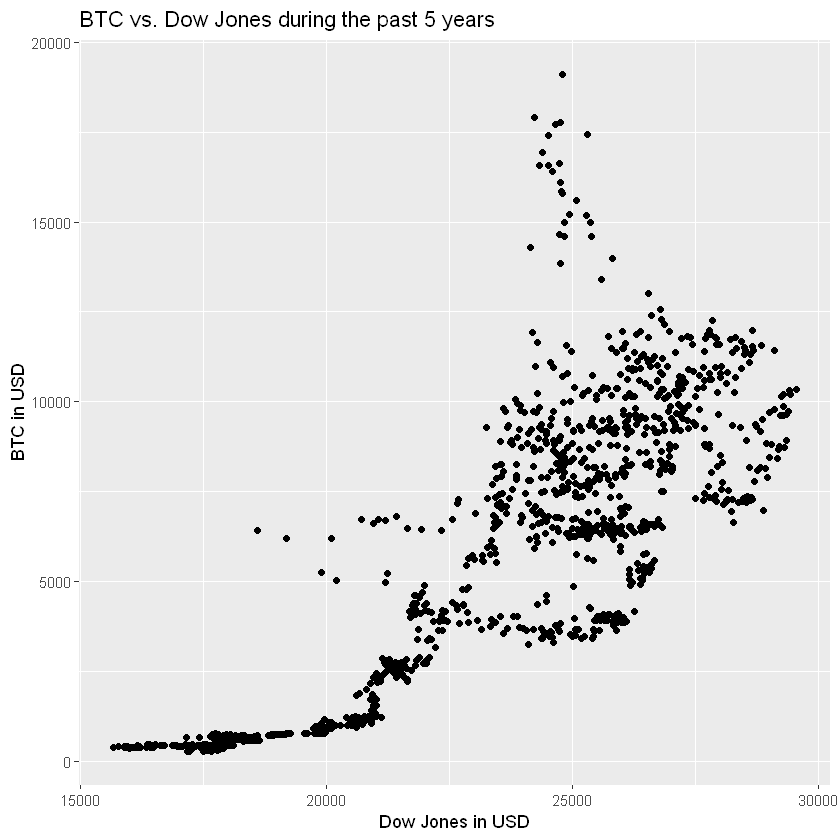

In [ ]:
ggplot(df, aes(DowJones, BTC)) + 
  geom_point() +
  ggtitle('BTC vs. Dow Jones during the past 5 years') +
  labs(x="Dow Jones in USD", y="BTC in USD")

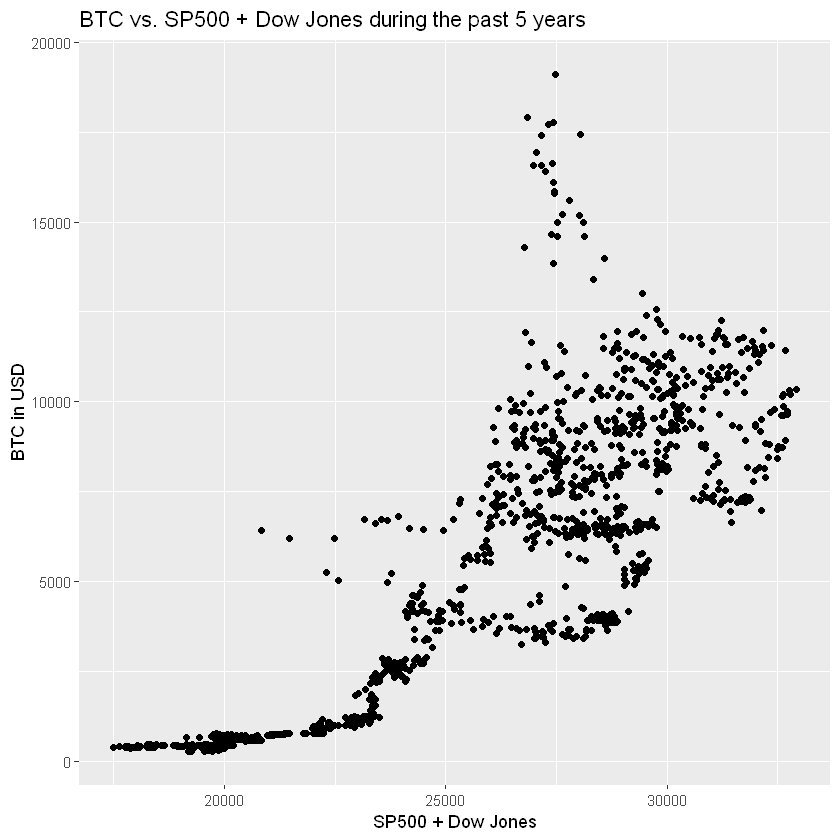

In [ ]:
ggplot(df, aes(SP500+DowJones, BTC)) + 
  geom_point() +
  ggtitle('BTC vs. SP500 + Dow Jones during the past 5 years') +
  labs(x="SP500 + Dow Jones", y="BTC in USD")

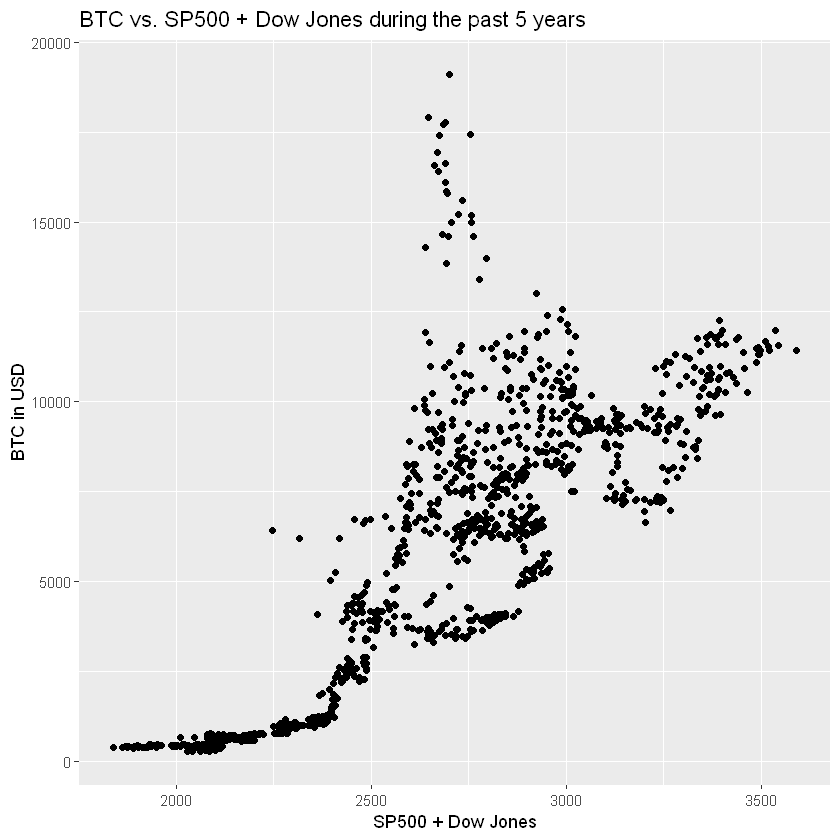

In [ ]:
ggplot(df, aes((SP500+log(DowJones)), BTC)) + 
  geom_point() +
  ggtitle('BTC vs. SP500 + Dow Jones during the past 5 years') +
  labs(x="SP500 + Dow Jones", y="BTC in USD")

In [ ]:
# Linear Regression Model
lmfit <- lm(BTC ~ SP500 + log(DowJones), data = df)
summary(lmfit)


Call:
lm(formula = BTC ~ SP500 + log(DowJones), data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-3837.4 -1413.1  -137.6   903.6 12486.3 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)   -1.205e+05  1.255e+04  -9.602  < 2e-16 ***
SP500          3.908e+00  5.775e-01   6.768 2.00e-11 ***
log(DowJones)  1.153e+04  1.395e+03   8.260 3.67e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2181 on 1256 degrees of freedom
Multiple R-squared:  0.7124,	Adjusted R-squared:  0.7119 
F-statistic:  1555 on 2 and 1256 DF,  p-value: < 2.2e-16


In [ ]:
lmfitpredict <- predict(lmfit, data = df)
lmrmse <- postResample(lmfitpredict, df$BTC)
print(lmrmse)

        RMSE     Rsquared          MAE 
2178.0369878    0.7123543 1515.0231243 


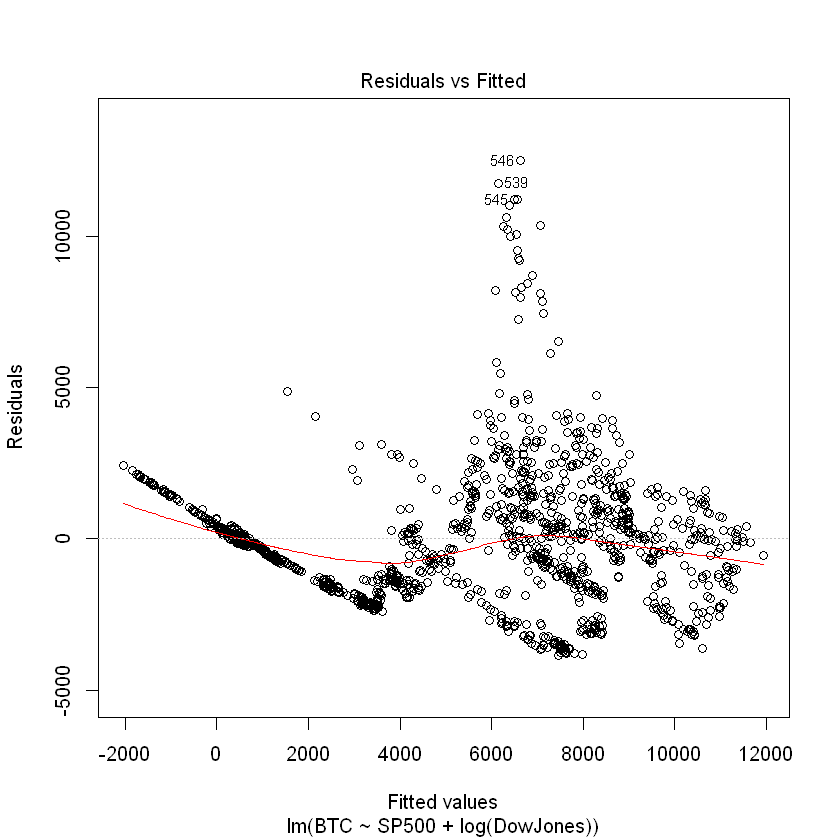

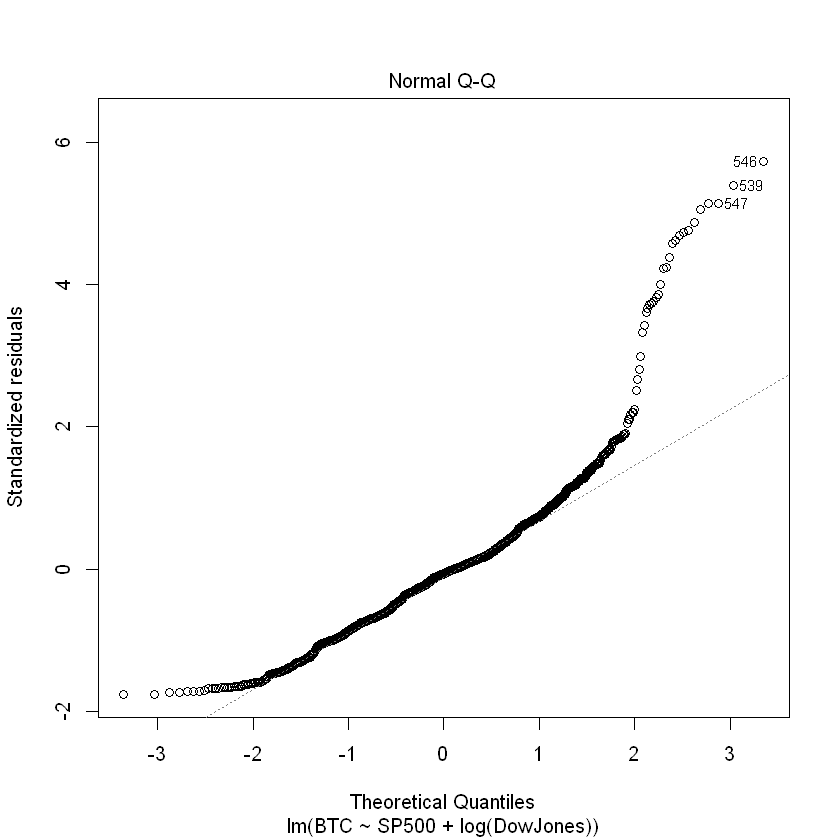

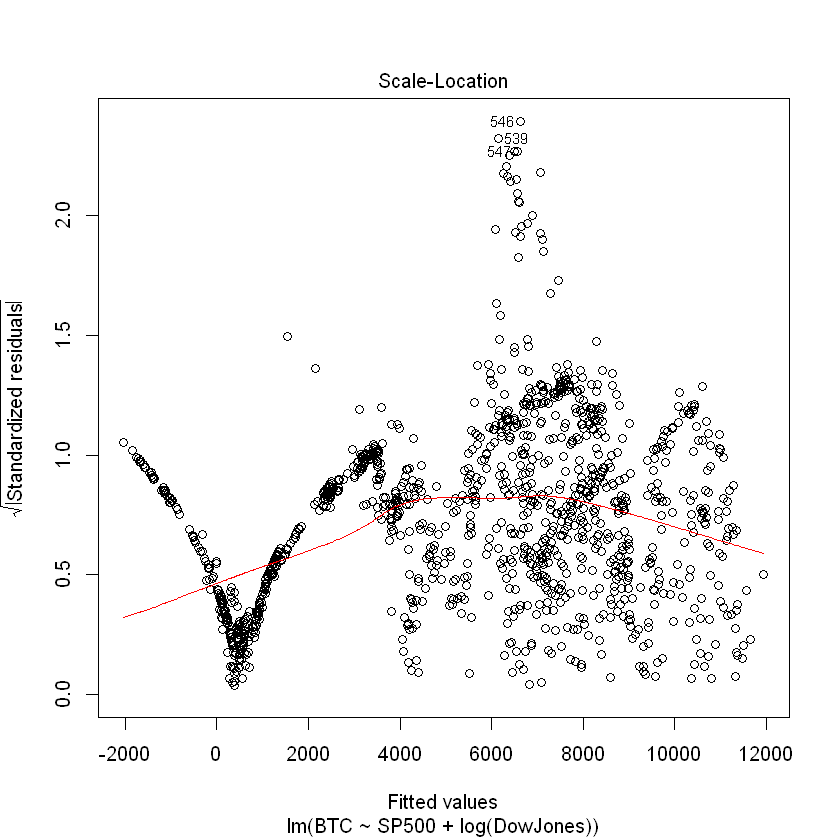

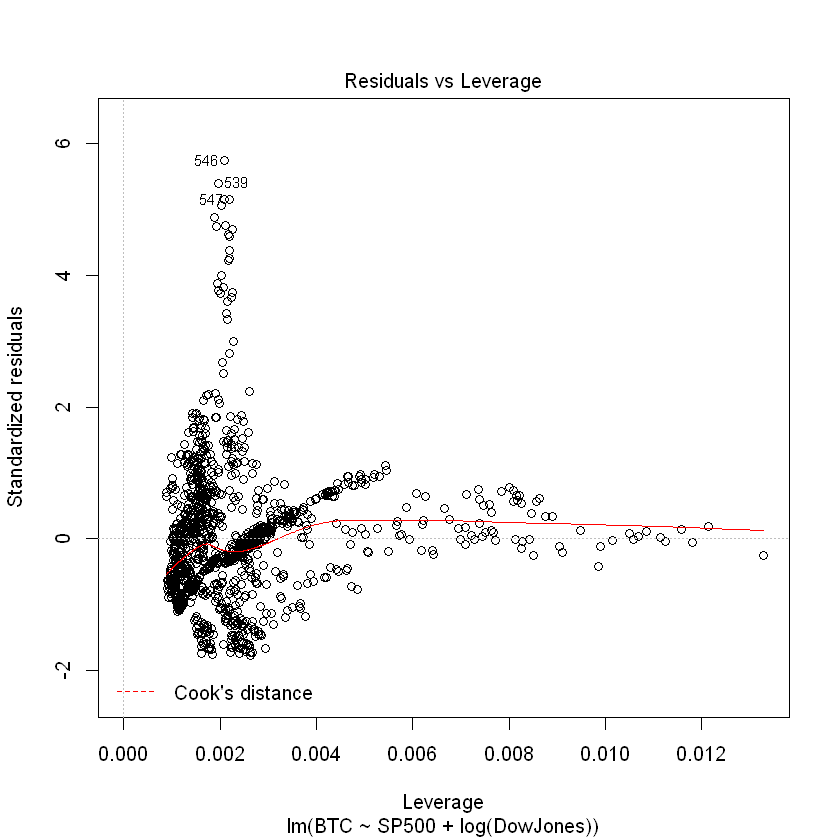

In [ ]:
plot(lmfit)

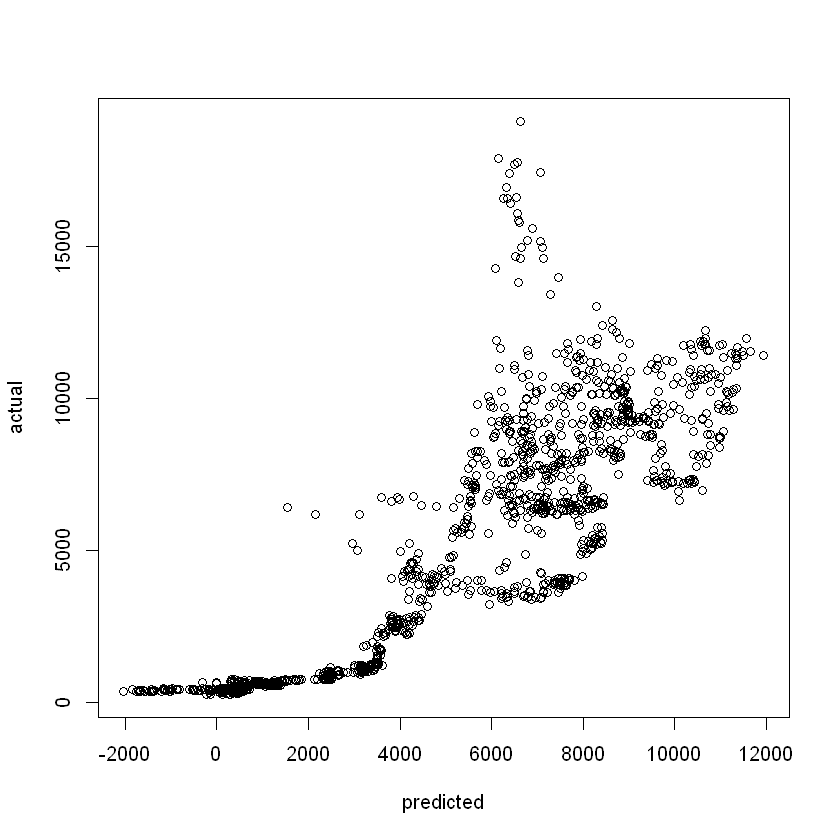

In [ ]:
 plot(predict(lmfit),df$BTC,
      xlab="predicted",ylab="actual")

### Linear kernel SVM model

In [ ]:
#Support vector machine
svmmodel <- svm(BTC ~ SP500 + log(DowJones), data = df, kernel = 'linear')
print(svmmodel)


Call:
svm(formula = BTC ~ SP500 + log(DowJones), data = df, kernel = "linear")


Parameters:
   SVM-Type:  eps-regression 
 SVM-Kernel:  linear 
       cost:  1 
      gamma:  0.5 
    epsilon:  0.1 


Number of Support Vectors:  978



        RMSE     Rsquared          MAE 
2229.7069001    0.7056983 1480.0475994 


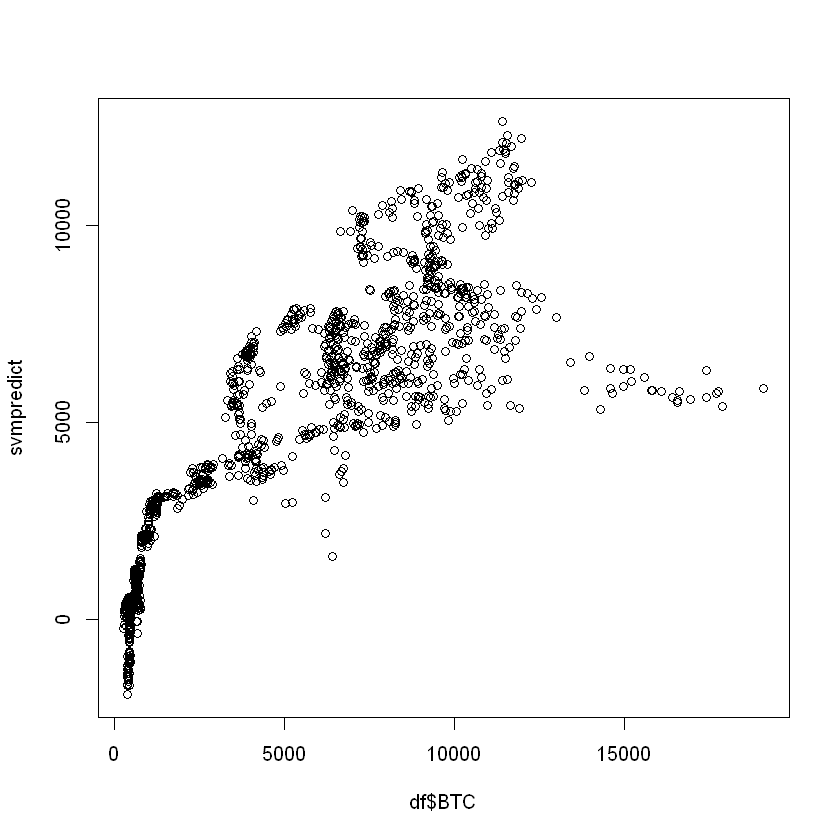

In [ ]:
svmpredict <- predict(svmmodel, data = df)
svmrmse <- postResample(svmpredict, df$BTC)
print(svmrmse)
plot(df$BTC, svmpredict)

### Radial kernel SVM model

In [ ]:
radialsvm <- svm(BTC ~ SP500 + log(DowJones), data = df, kernel = 'radial')
summary(radialsvm)


Call:
svm(formula = BTC ~ SP500 + log(DowJones), data = df, kernel = "radial")


Parameters:
   SVM-Type:  eps-regression 
 SVM-Kernel:  radial 
       cost:  1 
      gamma:  0.5 
    epsilon:  0.1 


Number of Support Vectors:  687






        RMSE     Rsquared          MAE 
1966.2768285    0.7694248 1142.1007078 


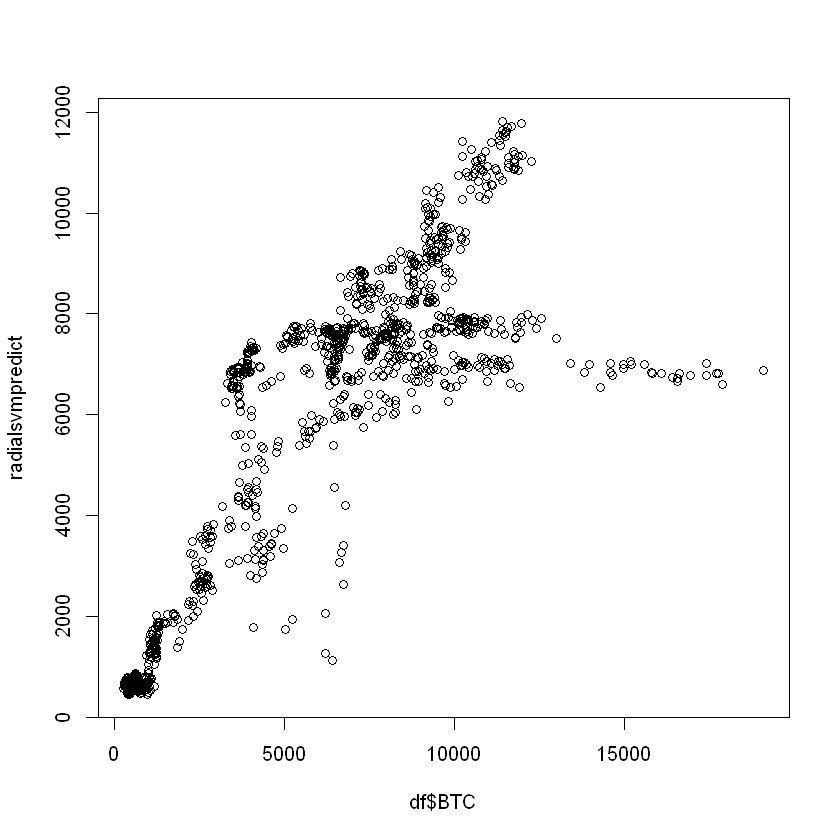

In [ ]:
radialsvmpredict <- predict(radialsvm, data = df)
radialsvmrmse <- postResample(radialsvmpredict, df$BTC)
print(radialsvmrmse)
plot(df$BTC, radialsvmpredict)

## Summary

For our project we trained a linear regression model to model the price of bitcoin using the prices of S&P 500 and Dow Jones, which are two large stock market indices that measure and track the prices of many large US companies. We had to try different variations of the linear model equation to get the one with the best predictive significance and settled on modeling bitcoin price by S&P 500 and the log of  Dow Jones. We took the log because the Dow Jones is almost 10 times larger than S&P 500, so taking the log brought it down to a closer range of S&P 500. The lm linear model had an r squared value of 0.71 and the linear kernel SVM model had a r square value of 0.70 and the radial kernel SVM model had a r square value of 0.76 which shows that the radial kernel SVM model was the best.


## Struggles and Roadblocks

One roadblock that we encountered was that in the qrmlibrary, we could not get all the historical data for bitcoin. This is why we could only look at the past 5 years because we could not get access to data from the past 10 years.


Another struggle we had was that the historical prices for the crypto currencies had missing data. So for this, we had to find a function that could fill in the missing data with interpolations and for this we used the na.approx function.

The last and largest issue was that it was hard to find a variable that could explain the sudden increase in bitcoin prices in late 2017. It was not easy to find variables that had high correlation to bitcoin prices.

## Conclusion

Overall it was interesting to look at the historical prices of various cryptocurrencies and then to try modeling the price of bitcoin using various US market prices. We ended up using S&P 500 and Dow Jones in our linear regression model to predict bitcoin prices. It did make sense that overall, bitcoin prices showed a strong relationship with large US stock market indices because when the markets are doing well, it would make sense that people would also be interested in investing in cryptocurrencies more as well. The radial kernel SVM model did better than the linear kernel SVM model and a linear model.

## Contributions

Previous publications have tried to use several factors to predict cryptocurrency prices such as sentiment in news and online communities. In particular many have used psychological aspects to inform crypto currency price models such as whether there is a bearish or bullish cycle going on. On the other hand, we tried to focus on the prices of other important financial markets and checked a wide range of stock market indices, to commodities, and even the US Treasury yields.

## References

https://cran.r-project.org/web/packages/qrmtools/qrmtools.pdf

https://www.nerdwallet.com/article/investing/cryptocurrency-7-things-to-know

https://coinrivet.com/guides/exchanges/why-does-cryptocurrency-price-change

https://www.quandl.com/data/WGC/GOLD_DAILY_USD-Gold-Prices-Daily-Currency-USD

https://www.quandl.com/data/FRED/DCOILBRENTEU-Crude-Oil-Prices-Brent-Europe

https://www.quandl.com/data/FED/SVENY-US-Treasury-Zero-Coupon-Yield-Curve

https://www.newsbtc.com/news/bitcoin/model-bitcoin-price-drop-8000-bears-done/

https://cointelegraph.com/news/the-three-most-controversial-bitcoin-price-models-and-what-they-predict

https://www.kdnuggets.com/2017/03/building-regression-models-support-vector-regression.html